In [1]:
%pylab inline

Populating the interactive namespace from numpy and matplotlib


In [2]:
from amstools import *

# Load pipeline.json

In [34]:
nb_bcc=Pipeline.read_json("Nb_bcc_pipeline.json")

dict of steps

In [35]:
nb_bcc.steps

{'Enn-fine': <amstools.pipeline.amstoolssteps.nnexpansionstep.AMStoolsNNExpansionStep at 0x7faf4a331520>,
 'relax': <amstools.pipeline.amstoolssteps.relaxation.AMStoolsFullRelaxationStep at 0x7faf4a171580>,
 'murnaghan': <amstools.pipeline.amstoolssteps.murnaghanstep.AMStoolsMurnaghanStep at 0x7faf4a171be0>,
 'elastic': <amstools.pipeline.amstoolssteps.elasticmatrixstep.AMStoolsElasticmatrixStep at 0x7faf4a174f10>,
 'phonons': <amstools.pipeline.amstoolssteps.phonopystep.AMStoolsPhonopyStep at 0x7faf4a17e520>}

In [36]:
nb_bcc['elastic'].value['C']

array([[239.72015242, 134.28956083, 134.28956083,   0.        ,
          0.        ,   0.        ],
       [134.28956083, 239.72015242, 134.28956083,   0.        ,
          0.        ,   0.        ],
       [134.28956083, 134.28956083, 239.72015242,   0.        ,
          0.        ,   0.        ],
       [  0.        ,   0.        ,   0.        ,  15.48310685,
          0.        ,   0.        ],
       [  0.        ,   0.        ,   0.        ,   0.        ,
         15.48310685,   0.        ],
       [  0.        ,   0.        ,   0.        ,   0.        ,
          0.        ,  15.48310685]])

## Get phonons

In [5]:
phonons=nb_bcc['phonons']

In [6]:
ph=phonons.phonopy

In [7]:
ph.run_mesh(mesh=50)

In [8]:
ph.run_total_dos()

<module 'matplotlib.pyplot' from '/home/users/lysogy36/miniconda3/envs/ace/lib/python3.8/site-packages/matplotlib/pyplot.py'>

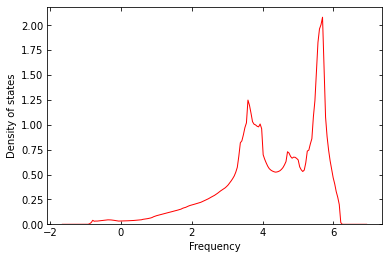

In [9]:
ph.plot_total_DOS()

## Output structures

Output structures are stored in `step.output_structures_dict`

### for elastic

In [13]:
nb_bcc['elastic'].output_structures_dict

{'s_e_0': Atoms(symbols='Nb', pbc=True, cell=[[-1.6546988600267527, 1.6546988600267527, 1.6546988600267527], [1.6546988600267527, -1.6546988600267527, 1.6546988600267527], [1.6546988600267527, 1.6546988600267527, -1.6546988600267527]], masses=..., calculator=SinglePointCalculator(...)),
 's_01_e_m0_01500': Atoms(symbols='Nb', pbc=True, cell=[[-1.6296893777199088, 1.6296893777199088, 1.6296893777199088], [1.6296893777199088, -1.6296893777199088, 1.6296893777199088], [1.6296893777199088, 1.6296893777199088, -1.6296893777199088]], masses=..., calculator=SinglePointCalculator(...)),
 's_01_e_m0_00750': Atoms(symbols='Nb', pbc=True, cell=[[-1.6422417278262422, 1.6422417278262422, 1.6422417278262422], [1.6422417278262422, -1.6422417278262422, 1.6422417278262422], [1.6422417278262422, 1.6422417278262422, -1.6422417278262422]], masses=..., calculator=SinglePointCalculator(...)),
 's_01_e_0_00750': Atoms(symbols='Nb', pbc=True, cell=[[-1.6670629088714448, 1.6670629088714448, 1.6670629088714448]

In [17]:
# DFT values in atoms.calc.results dict
nb_bcc['elastic'].output_structures_dict['s_01_e_0_01500'].calc.results

{'energy': -10.19612431,
 'forces': array([[0., 0., 0.]]),
 'stress': array([ 0.04425783,  0.04425783,  0.04425783, -0.        ,  0.        ,
         0.        ]),
 'free_energy': -10.20013441,
 'magmom': 0.0,
 'magmoms': array([0.]),
 'dipole': array([[0., 0., 0.]])}

### for Phonons

In [24]:
output_atoms = phonons.output_structures_dict['supercell_phonon_0']

In [25]:
output_atoms

Atoms(symbols='Nb64', pbc=True, cell=[[-6.618795440107011, 6.618795440107011, 6.618795440107011], [6.618795440107011, -6.618795440107011, 6.618795440107011], [6.618795440107011, 6.618795440107011, -6.618795440107011]], initial_magmoms=..., calculator=SinglePointCalculator(...))

In [21]:
output_atoms.calc

In [22]:
output_atoms.calc.results

{'energy': -653.83841471,
 'forces': array([[ 4.320824e-02, -4.320824e-02, -4.320824e-02],
        [-1.148809e-02,  1.148809e-02,  1.148809e-02],
        [ 4.939930e-03, -4.939930e-03, -4.939930e-03],
        [-1.114128e-02,  1.114128e-02,  1.114128e-02],
        [-4.446800e-03,  4.446800e-03, -2.155610e-03],
        [-7.362000e-05,  7.362000e-05,  4.871570e-03],
        [ 6.983800e-04, -6.983800e-04,  2.855840e-03],
        [-1.780560e-03,  1.780560e-03, -2.834700e-03],
        [ 6.749000e-04, -6.749000e-04,  3.580720e-03],
        [ 1.730730e-03, -1.730730e-03,  5.651100e-04],
        [-8.254100e-04,  8.254100e-04, -4.128750e-03],
        [ 1.778150e-03, -1.778150e-03,  6.266000e-04],
        [-4.631820e-03,  4.631820e-03, -2.321700e-03],
        [-1.760170e-03,  1.760170e-03, -2.787810e-03],
        [ 6.866200e-04, -6.866200e-04,  2.926090e-03],
        [-1.451300e-04,  1.451300e-04,  4.717790e-03],
        [-4.446800e-03, -2.155610e-03,  4.446800e-03],
        [-7.362000e-05,  4.87

# Rerun pipeline with potential

In [26]:
from pyace import PyACECalculator

In [27]:
calc=PyACECalculator("/home/users/lysogy36/acefit/Ni-Nb/5-Ni-Nb-FM-ZBL-upfit-24Oct23/NiNb-5-FM-ZBL.yaml")

## Rerun pipeline with new calc

In [29]:
nb_bcc_ace = nb_bcc.rerun_for(calc)

2024-08-26 16:53:35,768 - root - INFO - =======================
2024-08-26 16:53:35,769 - root - INFO - Step: Enn-fine
2024-08-26 16:53:36,146 - root - INFO - Job is done
2024-08-26 16:53:36,147 - root - INFO - Step status: finished
2024-08-26 16:53:36,147 - root - INFO - =======================
2024-08-26 16:53:36,156 - root - INFO - =======================
2024-08-26 16:53:36,157 - root - INFO - Step: relax
2024-08-26 16:53:36,206 - root - INFO - Job is done
2024-08-26 16:53:36,207 - root - INFO - Step status: finished
2024-08-26 16:53:36,208 - root - INFO - =======================
2024-08-26 16:53:36,221 - root - INFO - =======================
2024-08-26 16:53:36,222 - root - INFO - Step: murnaghan
2024-08-26 16:53:36,238 - root - INFO - Job is done
2024-08-26 16:53:36,239 - root - INFO - Step status: finished
2024-08-26 16:53:36,240 - root - INFO - =======================
2024-08-26 16:53:36,268 - root - INFO - =======================
2024-08-26 16:53:36,269 - root - INFO - Step: e

! BAD OPTIMIZATION, energy increases from -9.3945281875675 to -9.3945281875675
! BAD OPTIMIZATION, energy increases from -9.3945281875675 to -9.3945281875675
! BAD OPTIMIZATION, energy increases from -9.3945281875675 to -9.3945281875675
! BAD OPTIMIZATION, energy increases from -9.395486356052297 to -9.395486356052297
! BAD OPTIMIZATION, energy increases from -9.395486356052297 to -9.395486356052297
! BAD OPTIMIZATION, energy increases from -9.395486356052297 to -9.395486356052297


2024-08-26 16:53:41,322 - root - INFO - Job is done
2024-08-26 16:53:41,323 - root - INFO - Step status: finished
2024-08-26 16:53:41,323 - root - INFO - =======================


## Compare

#### E-V

In [41]:
nb_bcc['murnaghan'].value

{'volume': array([16.28984085, 16.65183731, 17.01383377, 17.37583023, 17.7378267 ,
        18.09982316, 18.46181962, 18.82381609, 19.18581255, 19.54780901,
        19.90980548]),
 'energy': array([-10.10381442, -10.14704562, -10.1791806 , -10.20122719,
        -10.21406175, -10.2184906 , -10.21525112, -10.2049886 ,
        -10.18832054, -10.16581581, -10.13798696]),
 'pressure': array([ 0.13438034,  0.10230252,  0.07313099,  0.04655172,  0.02230188,
         0.00017237, -0.02003491, -0.03849268, -0.05532499, -0.07065938,
        -0.08459783]),
 'equilibrium_energy': -10.218507460227151,
 'equilibrium_volume': 18.1224493419178,
 'equilibrium_bulk_modulus': 169.00331726011927,
 'equilibrium_b_prime': 3.5148134663158306,
 'energy_rms': 2.108282284889018e-06}

In [42]:
nb_bcc_ace['murnaghan'].value

OrderedDict([('volume',
              array([16.36958686, 16.73335546, 17.09712406, 17.46089266, 17.82466125,
                     18.18842985, 18.55219845, 18.91596704, 19.27973564, 19.64350424,
                     20.00727283])),
             ('energy',
              array([-9.28707673, -9.32785776, -9.35832665, -9.37933133, -9.3915327 ,
                     -9.39548636, -9.39170387, -9.38068954, -9.36295564, -9.33902272,
                     -9.30941211])),
             ('pressure',
              array([ 1.27236440e-01,  9.74892463e-02,  7.04129766e-02,  4.53697497e-02,
                      2.19650961e-02,  4.83850011e-06, -2.05705331e-02, -3.97515179e-02,
                     -5.75106102e-02, -7.38332729e-02, -8.87307683e-02])),
             ('equilibrium_energy', -9.395474463399623),
             ('equilibrium_volume', 18.188567924021676),
             ('equilibrium_bulk_modulus', 169.93726798577458),
             ('equilibrium_b_prime', 2.2342723672763087),
             ('energ

#### Elastic

In [32]:
nb_bcc['elastic'].value['C']

array([[239.72015242, 134.28956083, 134.28956083,   0.        ,
          0.        ,   0.        ],
       [134.28956083, 239.72015242, 134.28956083,   0.        ,
          0.        ,   0.        ],
       [134.28956083, 134.28956083, 239.72015242,   0.        ,
          0.        ,   0.        ],
       [  0.        ,   0.        ,   0.        ,  15.48310685,
          0.        ,   0.        ],
       [  0.        ,   0.        ,   0.        ,   0.        ,
         15.48310685,   0.        ],
       [  0.        ,   0.        ,   0.        ,   0.        ,
          0.        ,  15.48310685]])

In [33]:
nb_bcc_ace['elastic'].value['C']

array([[248.50304078, 131.07189165, 131.07189165,   0.        ,
          0.        ,   0.        ],
       [131.07189165, 248.50304078, 131.07189165,   0.        ,
          0.        ,   0.        ],
       [131.07189165, 131.07189165, 248.50304078,   0.        ,
          0.        ,   0.        ],
       [  0.        ,   0.        ,   0.        ,   8.96880875,
          0.        ,   0.        ],
       [  0.        ,   0.        ,   0.        ,   0.        ,
          8.96880875,   0.        ],
       [  0.        ,   0.        ,   0.        ,   0.        ,
          0.        ,   8.96880875]])

#### Phonons

In [48]:
def plot_dos(pipeline, ph_name='phonons', **kwargs):
    val_dict=pipeline[ph_name].value
    plt.plot(val_dict['dos_energies'], val_dict['dos_total'], **kwargs)

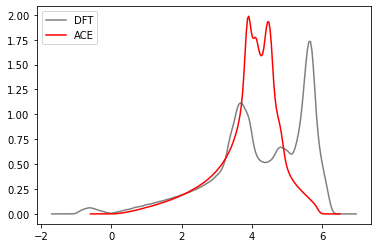

In [50]:
plot_dos(nb_bcc, label="DFT", color='gray')
plot_dos(nb_bcc_ace, label="ACE", color='red')
plt.legend()

Compare forces, used in phonons

In [52]:
val_dict_dft=nb_bcc['phonons'].value
val_dict_ace=nb_bcc_ace['phonons'].value

In [57]:
f_dft=val_dict_dft['phonopy_data']['supercell_forces_dict']['supercell_phonon_0']

In [58]:
f_ace=val_dict_ace['phonopy_data']['supercell_forces_dict']['supercell_phonon_0']

Text(0, 0.5, 'F_ACE')

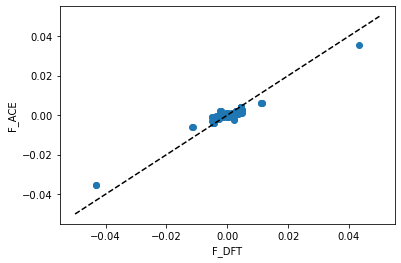

In [61]:
plt.scatter(f_dft.flatten(), f_ace.flatten())
plt.plot([-0.05,0.05],[-0.05,0.05], ls='--', color='k')
plt.xlabel('F_DFT')
plt.ylabel('F_ACE')